## NETWORK INTRUSION DETECTION SYSTEM USING DATA ANALYTICS BARGAVI(00920602023)

### ABOUT THE PROJECT
#### The Network Intrusion Detection System (NIDS) using Data Analytics is designed to identify suspicious and malicious network activities by analyzing patterns hidden inside network traffic data. In today’s digital world, networks face constant threats such as Denial of Service attacks, unauthorized access attempts, probing, and privilege escalation. To address these threats, the project applies data analytics and rule-based detection to classify network connections into different intrusion categories.

#### The system uses a dataset containing 43 manually defined network features, such as duration, protocol type, service request, flag indicators, packet errors, login attempts, and data transfer patterns. Each feature provides valuable information about how a connection behaves. By preprocessing and analyzing these features, the system can detect abnormal behaviour and raise alerts when an intrusion is identified.

#### This project is structured into modules covering data collection, preprocessing, analytical rule design, real-time detection, visualization, and a user-friendly interface. The rule-based engine uses thresholds, behaviour indicators, and statistical observations to classify traffic into one of the five intrusion types:

#### DoS (Denial of Service)

#### Probe (Scanning and information gathering)

#### R2L (Remote-to-Local unauthorized access)

#### U2R (User-to-Root privilege escalation)

####  Brute Force Attack

#### The project also includes a real-time monitoring module, allowing users to input connection parameters and instantly visualize whether the system detects an attack. The interactive user interface, built using widgets and Voila, makes the system easy to use, demonstrating how intrusion detection works in real operational scenarios.

#### Overall, this project showcases how data analytics can enhance cybersecurity by providing a simplified but effective method for detecting network intrusions. It helps students understand essential concepts such as feature engineering, rule-based detection, network behaviour analysis, and real-time monitoring. The system lays a strong foundation for advanced intrusion detection techniques and future machine learning–based security solutions.

### MODULE 1 : DATA COLLECTION AND LOADING

#### importing important libraries:

In [48]:
import pandas as pd
import numpy as np

#### loading and combining datasets

In [50]:
# Corrected column names
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count",
    "serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

# Load train and test with correct delimiter
train = pd.read_csv(r"C:\Users\Bargavi\Desktop\KDDTrain+.txt", names=COLUMNS, sep=r'\s*,\s*', engine='python', header=None)
test  = pd.read_csv(r"C:\Users\Bargavi\Desktop\KDDTest+.txt", names=COLUMNS, sep=r'\s*,\s*', engine='python', header=None)

combined = pd.concat([train, test], ignore_index=True)

print("Combined shape:", combined.shape)
print(combined['label'].head(20))


Combined shape: (148517, 43)
0          normal
1          normal
2         neptune
3          normal
4          normal
5         neptune
6         neptune
7         neptune
8         neptune
9         neptune
10        neptune
11        neptune
12         normal
13    warezclient
14        neptune
15        neptune
16         normal
17        ipsweep
18         normal
19         normal
Name: label, dtype: object


In [51]:
combined.head

<bound method NDFrame.head of         duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0              0           tcp  ftp_data   SF        491          0     0   
1              0           udp     other   SF        146          0     0   
2              0           tcp   private   S0          0          0     0   
3              0           tcp      http   SF        232       8153     0   
4              0           tcp      http   SF        199        420     0   
...          ...           ...       ...  ...        ...        ...   ...   
148512         0           tcp      smtp   SF        794        333     0   
148513         0           tcp      http   SF        317        938     0   
148514         0           tcp      http   SF      54540       8314     0   
148515         0           udp  domain_u   SF         42         42     0   
148516         0           tcp    sunrpc  REJ          0          0     0   

        wrong_fragment  urgent  hot  ...  dst

In [52]:
combined.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,148517.000000,1.485170e+05,1.485170e+05,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,...,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000
mean,276.779305,4.022795e+04,1.708885e+04,0.000215,0.020523,0.000202,0.189379,0.004323,0.402789,0.255062,...,119.462661,0.534521,0.084103,0.145932,0.030584,0.256122,0.251304,0.136220,0.136397,19.278480
std,2460.683131,5.409612e+06,3.703525e+06,0.014677,0.240069,0.019417,2.013160,0.072248,0.490461,22.231375,...,111.232318,0.448061,0.194102,0.308638,0.108975,0.428500,0.429719,0.322741,0.335282,2.739757
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,72.000000,0.600000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.780000e+02,5.710000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.050000,0.010000,0.600000,0.500000,0.000000,0.000000,21.000000
max,57715.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,101.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [53]:
combined.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty'],
      dtype='object')

In [54]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     148517 non-null  int64  
 1   protocol_type                148517 non-null  object 
 2   service                      148517 non-null  object 
 3   flag                         148517 non-null  object 
 4   src_bytes                    148517 non-null  int64  
 5   dst_bytes                    148517 non-null  int64  
 6   land                         148517 non-null  int64  
 7   wrong_fragment               148517 non-null  int64  
 8   urgent                       148517 non-null  int64  
 9   hot                          148517 non-null  int64  
 10  num_failed_logins            148517 non-null  int64  
 11  logged_in                    148517 non-null  int64  
 12  num_compromised              148517 non-null  int64  
 13 

## MODULE 2 : DATA CLEANING AND PRE-PROCESSING  

In [55]:
combined.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [56]:
combined.duplicated().sum()

np.int64(610)

In [57]:
combined.drop_duplicates(inplace=True)

In [58]:
combined.duplicated().sum()

np.int64(0)

#### now there are no duplicate or null values

In [59]:
combined.info

<bound method DataFrame.info of         duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0              0           tcp  ftp_data   SF        491          0     0   
1              0           udp     other   SF        146          0     0   
2              0           tcp   private   S0          0          0     0   
3              0           tcp      http   SF        232       8153     0   
4              0           tcp      http   SF        199        420     0   
...          ...           ...       ...  ...        ...        ...   ...   
148510         1           tcp      smtp   SF       2599        293     0   
148512         0           tcp      smtp   SF        794        333     0   
148513         0           tcp      http   SF        317        938     0   
148514         0           tcp      http   SF      54540       8314     0   
148516         0           tcp    sunrpc  REJ          0          0     0   

        wrong_fragment  urgent  hot  ...  d

In [60]:
columns_to_drop = [
    'num_outbound_cmds', 'is_host_login', 'urgent',
    'num_shells', 'num_access_files', 'num_file_creations',
    'is_guest_login', 'land',
    'srv_serror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'srv_diff_host_rate', 'dst_host_srv_count',
    'dst_host_diff_srv_rate', 'dst_host_srv_diff_host_rate'
]


In [61]:
combined = combined.drop(columns=columns_to_drop)

In [62]:
combined.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'wrong_fragment', 'hot', 'num_failed_logins', 'logged_in',
       'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'count',
       'srv_count', 'serror_rate', 'rerror_rate', 'diff_srv_rate',
       'dst_host_count', 'dst_host_same_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'label', 'difficulty'],
      dtype='object')

#### we dropped the above columns because -  srv_serror_rate','srv_rerror_rate','same_srv_rate','srv_diff_host_rate','dst_host_srv_count','dst_host_diff_srv_rate','dst_host_srv_diff_host_rate'(These columns basically repeat the info already present in: 'serror_rate,rerror_rate,diff_srv_rate,count / srv_count)

#### • we dropped these columns -  'num_outbound_cmds', 'is_host_login','urgent' because these columns are always zero

#### • we dropped these columns - 'num_shells', 'num_access_files','num_file_creations','is_guest_login','land' - as they are too sparse

In [63]:
# Normalizing Labels 
def normalize_label(s):
    if isinstance(s, str):
        s = s.strip().lower()
        if s.endswith('.'):
            s = s[:-1]
    return s

combined['label_norm'] = combined['label'].apply(normalize_label)

# Mapping labels to 5 categories 
attack_map = {
    # Normal
    'normal': 'normal',

    # DoS attacks
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS',

    # Probe attacks
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe','mscan':'Probe','saint':'Probe',

    # R2L attacks
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L','phf':'R2L','spy':'R2L',
    'warezclient':'R2L','warezmaster':'R2L','sendmail':'R2L','named':'R2L','snmpgetattack':'R2L',
    'snmpguess':'R2L','xlock':'R2L','xsnoop':'R2L','worm':'R2L',

    # U2R attacks
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R','httptunnel':'U2R',
    'ps':'U2R','sqlattack':'U2R','xterm':'U2R'
}

def map_5class(label):
    return attack_map.get(label, 'other')

combined['label_5'] = combined['label_norm'].apply(map_5class)

# Step 3: Map labels to 2 classes (normal vs attack)
combined['label_2'] = combined['label_5'].apply(lambda x: 'normal' if x=='normal' else 'attack')

# Verify
combined[['label', 'label_norm', 'label_5', 'label_2']].head()


,label,label_norm,label_5,label_2
0,normal,normal,normal,normal
1,normal,normal,normal,normal
2,neptune,neptune,DoS,attack
3,normal,normal,normal,normal
4,normal,normal,normal,normal


## MODULE 3 : RULE BASED INTRUSION DETECTION 

In [64]:
def detect_rules(combined, thresholds=None):
    defaults = {
        'dos_count_threshold': 100,
        'dos_serror_rate': 0.5,
        'probe_diff_srv_rate': 0.6,
        'r2l_failed_logins': 2,
        'u2r_root_indicators': 1,
        'large_packet_bytes': 200000
    }
    if thresholds:
        defaults.update(thresholds)

    combined = combined.copy()
    combined['predicted'] = 'normal'

    # Fill na
    for col in ['count','serror_rate','diff_srv_rate','num_failed_logins',
                'logged_in','num_root','root_shell','su_attempted','src_bytes','dst_bytes']:
        combined[col] = pd.to_numeric(combined[col], errors='coerce').fillna(0)

    # DoS
    mask_dos = (combined['count'] >= defaults['dos_count_threshold']) & \
               (combined['serror_rate'] >= defaults['dos_serror_rate'])
    combined.loc[mask_dos, 'predicted'] = 'DoS'

    # Probe
    mask_probe = (combined['diff_srv_rate'] >= defaults['probe_diff_srv_rate']) & (~mask_dos)
    combined.loc[mask_probe, 'predicted'] = 'Probe'

    # R2L
    mask_r2l = (combined['num_failed_logins'] >= defaults['r2l_failed_logins']) & \
               (combined['logged_in'] == 0) & (~mask_dos) & (~mask_probe)
    combined.loc[mask_r2l, 'predicted'] = 'R2L'

    # U2R
    mask_u2r = ((combined['num_root'] >= defaults['u2r_root_indicators']) |
                (combined['root_shell'] >= defaults['u2r_root_indicators']) |
                (combined['su_attempted'] >= defaults['u2r_root_indicators'])) & \
               (~mask_dos) & (~mask_probe) & (~mask_r2l)
    combined.loc[mask_u2r, 'predicted'] = 'U2R'

    # Other anomalies
    mask_other = ((combined['src_bytes'] >= defaults['large_packet_bytes']) |
                  (combined['dst_bytes'] >= defaults['large_packet_bytes'])) & \
                 (combined['predicted'] == 'normal')
    combined.loc[mask_other, 'predicted'] = 'other'

    return combined


In [65]:
detected = detect_rules(combined)
detected.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,num_failed_logins,logged_in,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,label_norm,label_5,label_2,predicted
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.00,0.00,0.05,0.00,normal,20,normal,normal,normal,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.00,0.00,0.00,normal,15,normal,normal,normal,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,1.00,1.00,0.00,0.00,neptune,19,neptune,DoS,attack,DoS
3,0,tcp,http,SF,232,8153,0,0,0,1,...,0.03,0.01,0.00,0.01,normal,21,normal,normal,normal,normal
4,0,tcp,http,SF,199,420,0,0,0,1,...,0.00,0.00,0.00,0.00,normal,21,normal,normal,normal,normal


In [66]:
alerts = detected[detected['predicted'] != 'normal']
alerts.to_csv("alerts_combined.csv", index=False)

print("Total alerts:", len(alerts))
alerts.head()


Total alerts: 37396


,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,num_failed_logins,logged_in,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,label_norm,label_5,label_2,predicted
2,0,tcp,private,S0,0,0,0,0,0,0,...,1.0,1.0,0.0,0.0,neptune,19,neptune,DoS,attack,DoS
6,0,tcp,private,S0,0,0,0,0,0,0,...,1.0,1.0,0.0,0.0,neptune,21,neptune,DoS,attack,DoS
7,0,tcp,private,S0,0,0,0,0,0,0,...,1.0,1.0,0.0,0.0,neptune,21,neptune,DoS,attack,DoS
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,1.0,1.0,0.0,0.0,neptune,21,neptune,DoS,attack,DoS
9,0,tcp,private,S0,0,0,0,0,0,0,...,1.0,1.0,0.0,0.0,neptune,21,neptune,DoS,attack,DoS


In [67]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = detected['label_5']
y_pred = detected['predicted']

labels = ['normal','DoS','Probe','R2L','U2R','other']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred, labels=labels))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels, zero_division=0))


Accuracy: 0.7269838479585145

Confusion Matrix:
[[73912    35  1854     5   678   483]
 [23390 29396   199     0     0     0]
 [ 9713    76  4150     1     3    11]
 [ 3332     0    85     3    28   301]
 [  164     1    20     0    65     2]
 [    0     0     0     0     0     0]]

Classification Report:
              precision    recall  f1-score   support

      normal       0.67      0.96      0.79     76967
         DoS       1.00      0.55      0.71     52985
       Probe       0.66      0.30      0.41     13954
         R2L       0.33      0.00      0.00      3749
         U2R       0.08      0.26      0.13       252
       other       0.00      0.00      0.00         0

    accuracy                           0.73    147907
   macro avg       0.46      0.35      0.34    147907
weighted avg       0.78      0.73      0.70    147907



## MODULE 4 : RESULTS AND VISUALISATION 

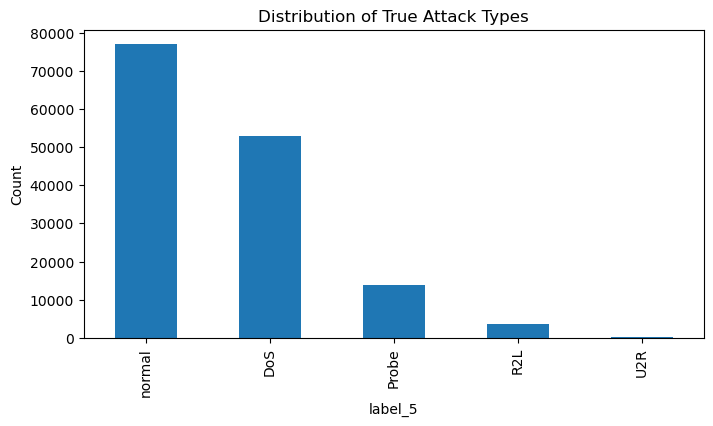

In [68]:
import matplotlib.pyplot as plt
combined['label_5'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Distribution of True Attack Types")
plt.ylabel("Count")
plt.show()


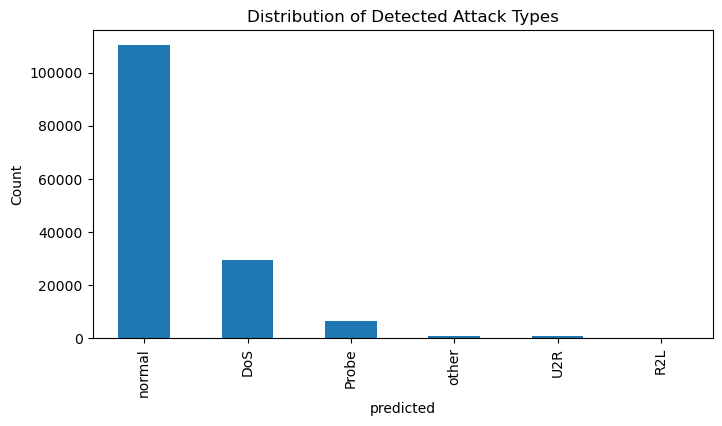

In [69]:
detected['predicted'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title("Distribution of Detected Attack Types")
plt.ylabel("Count")
plt.show()


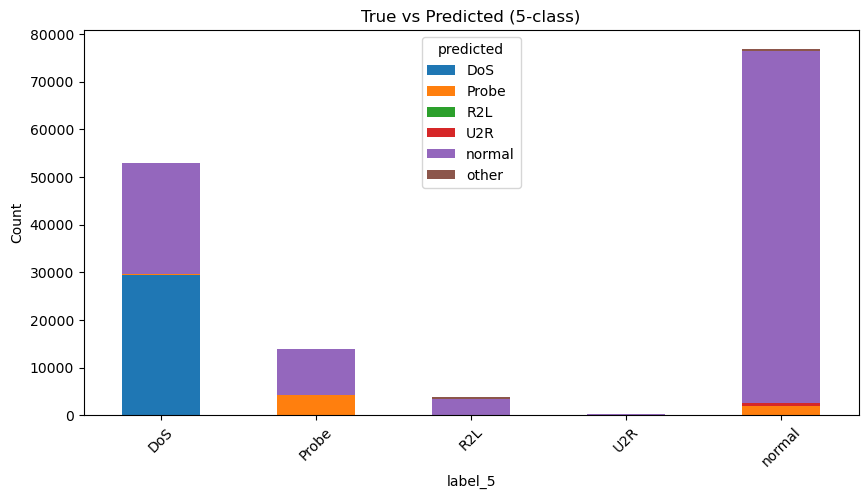

In [70]:
pd.crosstab(combined['label_5'], detected['predicted']).plot(
    kind='bar', stacked=True, figsize=(10,5)
)
plt.title("True vs Predicted (5-class)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [71]:
alerts.sample(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,wrong_fragment,hot,num_failed_logins,logged_in,...,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,label_norm,label_5,label_2,predicted
123751,14089,udp,other,SF,147,105,0,0,0,0,...,0.00,0.0,0.00,0.0,normal,20,normal,normal,normal,Probe
15833,0,tcp,ftp,S0,0,0,0,0,0,0,...,1.00,1.0,0.00,0.0,neptune,19,neptune,DoS,attack,DoS
57114,0,tcp,ldap,S0,0,0,0,0,0,0,...,1.00,1.0,0.00,0.0,neptune,21,neptune,DoS,attack,DoS
9117,0,tcp,private,REJ,0,0,0,0,0,0,...,0.03,0.0,0.97,1.0,satan,17,satan,Probe,attack,Probe
85903,0,tcp,iso_tsap,S0,0,0,0,0,0,0,...,1.00,1.0,0.00,0.0,neptune,18,neptune,DoS,attack,DoS
99385,0,tcp,echo,S0,0,0,0,0,0,0,...,1.00,1.0,0.00,0.0,neptune,18,neptune,DoS,attack,DoS
49630,0,tcp,private,S0,0,0,0,0,0,0,...,1.00,1.0,0.00,0.0,neptune,21,neptune,DoS,attack,DoS
143984,0,tcp,imap4,SF,0,0,0,0,0,0,...,0.00,0.0,0.02,0.5,mscan,9,mscan,Probe,attack,Probe
74375,0,tcp,Z39_50,S0,0,0,0,0,0,0,...,1.00,1.0,0.00,0.0,neptune,18,neptune,DoS,attack,DoS
89452,0,tcp,link,S0,0,0,0,0,0,0,...,1.00,1.0,0.00,0.0,neptune,20,neptune,DoS,attack,DoS


## MODULE 5: REAL-TIME MONITORING

In [72]:
import time
import pandas as pd
import os


In [73]:
df_stream = combined.copy()

print("Streaming source loaded from memory!")
print("Total rows available:", len(df_stream))


Streaming source loaded from memory!
Total rows available: 147907


In [74]:
def detect_rules(df, thresholds=None):
    defaults = {
        'dos_count_threshold': 100,
        'dos_serror_rate': 0.5,
        'probe_diff_srv_rate': 0.6,
        'r2l_failed_logins': 2,
        'u2r_root_indicators': 1,
        'large_packet_bytes': 200000
    }

    if thresholds:
        defaults.update(thresholds)

    df = df.copy()
    df['predicted'] = 'normal'

    numeric_cols = [
        'count','serror_rate','diff_srv_rate','num_failed_logins','logged_in',
        'num_root','root_shell','su_attempted','src_bytes','dst_bytes'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # Rules
    mask_dos = (df['count'] >= defaults['dos_count_threshold']) & \
               (df['serror_rate'] >= defaults['dos_serror_rate'])
    df.loc[mask_dos, 'predicted'] = 'DoS'

    mask_probe = (df['diff_srv_rate'] >= defaults['probe_diff_srv_rate']) & (~mask_dos)
    df.loc[mask_probe, 'predicted'] = 'Probe'

    mask_r2l = (df['num_failed_logins'] >= defaults['r2l_failed_logins']) & \
               (df['logged_in'] == 0) & (~mask_dos) & (~mask_probe)
    df.loc[mask_r2l, 'predicted'] = 'R2L'

    mask_u2r = ((df['num_root'] >= defaults['u2r_root_indicators']) |
                (df['root_shell'] >= defaults['u2r_root_indicators']) |
                (df['su_attempted'] >= defaults['u2r_root_indicators'])) & \
               (~mask_dos) & (~mask_probe) & (~mask_r2l)
    df.loc[mask_u2r, 'predicted'] = 'U2R'

    mask_other = ((df['src_bytes'] >= defaults['large_packet_bytes']) |
                  (df['dst_bytes'] >= defaults['large_packet_bytes'])) & \
                 (df['predicted'] == 'normal')
    df.loc[mask_other, 'predicted'] = 'other'

    return df


In [75]:
batch_size = 200     # how many rows per batch
delay = 1.0          # seconds between batches
OUTPUT_ALERTS = "alerts_streaming.csv"

# If old file exists, remove it
if os.path.exists(OUTPUT_ALERTS):
    os.remove(OUTPUT_ALERTS)

print("Ready to start streaming :)")


Ready to start streaming :)


In [ ]:
total_rows = len(df_stream)
start = 0
batch_num = 0

print(" Starting real-time monitoring \n")

while start < total_rows:
    batch_num += 1
    end = min(start + batch_size, total_rows)

    # Take one batch
    batch = df_stream.iloc[start:end]

    # Detect attacks using rule-based engine
    detected = detect_rules(batch)

    # Extract alerts
    alerts = detected[detected['predicted'] != 'normal']

    # If alerts exist in this batch, save them
    if len(alerts) > 0:
        # Add extra info (batch number)
        alerts['batch'] = batch_num

        # Check if file exists (write header first time only)
        header = not os.path.exists(OUTPUT_ALERTS)

        # Save alerts to CSV in your notebook folder
        alerts.to_csv(OUTPUT_ALERTS, mode='a', index=False, header=header)

        print(f"[Batch {batch_num}] 🚨 ALERTS FOUND: {len(alerts)}")
        print(alerts[['label','predicted','count','serror_rate','diff_srv_rate']].head(), "\n")
    else:
        print(f"[Batch {batch_num}] No alerts detected.\n")

    # Move to next batch
    start = end

    # Simulate live network delay
    time.sleep(delay)

print("Streaming complete!")
print("Alerts saved to:", OUTPUT_ALERTS)


 Starting real-time monitoring 

[Batch 1] 🚨 ALERTS FOUND: 54
     label predicted  count  serror_rate  diff_srv_rate
2  neptune       DoS    123          1.0           0.07
6  neptune       DoS    166          1.0           0.06
7  neptune       DoS    117          1.0           0.06
8  neptune       DoS    270          1.0           0.05
9  neptune       DoS    133          1.0           0.06 



C:\Users\Bargavi\AppData\Local\Temp\ipykernel_8496\46595250.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts['batch'] = batch_num
C:\Users\Bargavi\AppData\Local\Temp\ipykernel_8496\46595250.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts['batch'] = batch_num


[Batch 2] 🚨 ALERTS FOUND: 62
       label predicted  count  serror_rate  diff_srv_rate
201  neptune       DoS    143         1.00           0.06
205   normal     Probe      2         0.00           1.00
206  neptune       DoS    201         1.00           0.06
209  neptune       DoS    124         1.00           0.05
210    satan     Probe    162         0.05           1.00 



C:\Users\Bargavi\AppData\Local\Temp\ipykernel_8496\46595250.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts['batch'] = batch_num


[Batch 3] 🚨 ALERTS FOUND: 55
       label predicted  count  serror_rate  diff_srv_rate
401  neptune       DoS    257          1.0           0.05
405   normal       U2R      1          0.0           0.00
408  neptune       DoS    257          1.0           0.05
414  neptune       DoS    132          1.0           0.06
417  neptune       DoS    290          1.0           0.06 



...

[Batch 218] 🚨 ALERTS FOUND: 53
         label predicted  count  serror_rate  diff_srv_rate
43401    satan     Probe    444         0.05           1.00
43405  neptune       DoS    280         1.00           0.06
43406  neptune       DoS    267         1.00           0.07
43425  neptune       DoS    227         1.00           0.05
43426   normal     Probe      2         0.50           1.00 



C:\Users\Bargavi\AppData\Local\Temp\ipykernel_8496\46595250.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts['batch'] = batch_num


[Batch 219] 🚨 ALERTS FOUND: 61
         label predicted  count  serror_rate  diff_srv_rate
43601    satan     Probe      5         0.00           1.00
43607  neptune       DoS    103         1.00           0.06
43613    satan     Probe     63         0.11           1.00
43615   normal     Probe      2         0.00           1.00
43616  neptune       DoS    134         1.00           0.07 



C:\Users\Bargavi\AppData\Local\Temp\ipykernel_8496\46595250.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts['batch'] = batch_num


[Batch 220] 🚨 ALERTS FOUND: 51
         label predicted  count  serror_rate  diff_srv_rate
43811  neptune       DoS    282         1.00           0.06
43813  neptune       DoS    208         1.00           0.06
43814  neptune       DoS    119         1.00           0.06
43815  neptune       DoS    290         1.00           0.06
43819  neptune       DoS    162         0.86           0.06 



## MODULE 6: USER INTERFACE AND OUTPUTS

In [43]:
import os
import io
import pandas as pd
import numpy as np
from IPython.display import display, clear_output
import ipywidgets as widgets
import matplotlib.pyplot as plt

# Use uploaded file path in this environment
UPLOADED_PATH = "sandbox:/mnt/data/KDDTest+.txt"   
LOCAL_FALLBACK = "KDDTest+.txt"                    
OUTPUT_ALERTS = "alerts_from_ui.csv"

print("Ready. If you're running locally, ensure your dataset file is in the notebook folder and change UPLOADED_PATH if needed.")


Ready. If you're running locally, ensure your dataset file is in the notebook folder and change UPLOADED_PATH if needed.


In [44]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
    "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count",
    "serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

def load_default_df():
    # 1) if you already have 'combined' in memory (from Module 1-5), use it:
    if 'combined' in globals():
        print("Using in-memory DataFrame: combined")
        return combined
    # 2) try the uploaded path (this environment)
    if os.path.exists(UPLOADED_PATH):
        try:
            df = pd.read_csv(UPLOADED_PATH, names=COLUMNS, sep=r'\s*,\s*', engine='python', header=None)
            print("Loaded from UPLOADED_PATH:", UPLOADED_PATH)
            return df
        except Exception as e:
            print("Tried reading UPLOADED_PATH, got:", e)
    # 3) try local fallback filename
    if os.path.exists(LOCAL_FALLBACK):
        try:
            df = pd.read_csv(LOCAL_FALLBACK, names=COLUMNS, sep=r'\s*,\s*', engine='python', header=None)
            print("Loaded from local fallback:", LOCAL_FALLBACK)
            return df
        except Exception as e:
            print("Tried reading local fallback, got:", e)
    print("No dataset found in memory or files.")
    return None

# load now for preview
df = load_default_df()
if df is not None:
    print("Dataset shape:", df.shape)
else:
    print("Please upload a dataset via the UI or place the file in the notebook folder.")


Using in-memory DataFrame: combined
Dataset shape: (147907, 31)


In [45]:
def detect_rules(df, thresholds=None):
    defaults = {
        'dos_count_threshold': 100,
        'dos_serror_rate': 0.5,
        'probe_diff_srv_rate': 0.6,
        'r2l_failed_logins': 2,
        'u2r_root_indicators': 1,
        'large_packet_bytes': 200000
    }
    if thresholds:
        defaults.update(thresholds)

    df_local = df.copy()
    df_local['predicted'] = 'normal'

    numeric_cols = [
        'count','serror_rate','diff_srv_rate','num_failed_logins','logged_in',
        'num_root','root_shell','su_attempted','src_bytes','dst_bytes'
    ]
    for col in numeric_cols:
        if col not in df_local.columns:
            df_local[col] = 0
        df_local[col] = pd.to_numeric(df_local[col], errors='coerce').fillna(0)

    # DoS
    mask_dos = (df_local['count'] >= defaults['dos_count_threshold']) & (df_local['serror_rate'] >= defaults['dos_serror_rate'])
    df_local.loc[mask_dos, 'predicted'] = 'DoS'

    # Probe
    mask_probe = (df_local['diff_srv_rate'] >= defaults['probe_diff_srv_rate']) & (~mask_dos)
    df_local.loc[mask_probe, 'predicted'] = 'Probe'

    # R2L
    mask_r2l = (df_local['num_failed_logins'] >= defaults['r2l_failed_logins']) & (df_local['logged_in'] == 0) & (~mask_dos) & (~mask_probe)
    df_local.loc[mask_r2l, 'predicted'] = 'R2L'

    # U2R
    mask_u2r = ((df_local['num_root'] >= defaults['u2r_root_indicators']) |
                (df_local['root_shell'] >= defaults['u2r_root_indicators']) |
                (df_local['su_attempted'] >= defaults['u2r_root_indicators'])) & (~mask_dos) & (~mask_probe) & (~mask_r2l)
    df_local.loc[mask_u2r, 'predicted'] = 'U2R'

    # Other anomalies
    mask_other = ((df_local['src_bytes'] >= defaults['large_packet_bytes']) | (df_local['dst_bytes'] >= defaults['large_packet_bytes'])) & (df_local['predicted'] == 'normal')
    df_local.loc[mask_other, 'predicted'] = 'other'

    return df_local


In [46]:
upload = widgets.FileUpload(accept='.csv,.txt', multiple=False, description='Upload CSV (optional)')
dos_count_w = widgets.IntSlider(value=100, min=10, max=2000, step=10, description='DoS count')
dos_serr_w = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, description='DoS serror')
probe_diff_w = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.01, description='Probe diff_srv')
r2l_fail_w = widgets.IntSlider(value=2, min=0, max=10, step=1, description='R2L fails')
u2r_ind_w = widgets.IntSlider(value=1, min=0, max=5, step=1, description='U2R ind')
run_btn = widgets.Button(description='Run Detection', button_style='success')
clear_btn = widgets.Button(description='Clear Output', button_style='warning')

controls_col = widgets.VBox([upload, dos_count_w, dos_serr_w, probe_diff_w, r2l_fail_w, u2r_ind_w, widgets.HBox([run_btn, clear_btn])])
display(controls_col)


In [47]:
out = widgets.Output(layout={'border': '1px solid black'})
display(out)

def get_dataframe_from_upload(uploader):
    if uploader.value:
        # read uploaded bytes into pandas
        key = list(uploader.value.keys())[0]
        content = uploader.value[key]['content']
        return pd.read_csv(io.BytesIO(content), names=COLUMNS, sep=r'\s*,\s*', engine='python', header=None)
    # fallback to previously loaded df variable
    if 'df' in globals() and df is not None:
        return df
    # try the environment uploaded path
    if os.path.exists(UPLOADED_PATH):
        return pd.read_csv(UPLOADED_PATH, names=COLUMNS, sep=r'\s*,\s*', engine='python', header=None)
    # local fallback
    if os.path.exists(LOCAL_FALLBACK):
        return pd.read_csv(LOCAL_FALLBACK, names=COLUMNS, sep=r'\s*,\s*', engine='python', header=None)
    return None

def on_run_clicked(b):
    with out:
        clear_output()
        print("Running detection... please wait (small demo processes quickly).")
        df_local = get_dataframe_from_upload(upload)
        if df_local is None:
            print("No dataset found. Upload or place file in notebook folder.")
            return
        thresholds = {
            'dos_count_threshold': dos_count_w.value,
            'dos_serror_rate': dos_serr_w.value,
            'probe_diff_srv_rate': probe_diff_w.value,
            'r2l_failed_logins': r2l_fail_w.value,
            'u2r_root_indicators': u2r_ind_w.value,
            'large_packet_bytes': 200000
        }
        detected = detect_rules(df_local, thresholds)
        # store for saving later
        globals()['detected'] = detected

        # summary
        total = detected.shape[0]
        alerts = detected[detected['predicted'] != 'normal']
        print(f"Total rows: {total}  | Alerts detected: {len(alerts)}")
        display(alerts.head(20))

        # plot predicted distribution
        fig, ax = plt.subplots(1,2, figsize=(10,3))
        detected['predicted'].value_counts().plot(kind='bar', ax=ax[0], title='Predicted (counts)')
        if 'label_5' in detected.columns:
            detected['label_5'].value_counts().plot(kind='bar', ax=ax[1], title='True label_5 (counts)')
        else:
            ax[1].set_visible(False)
        plt.tight_layout()
        display(fig)

        # save alerts to CSV
        if not alerts.empty:
            alerts.to_csv(OUTPUT_ALERTS, index=False)
            print(f"Alerts saved to file: {OUTPUT_ALERTS} (in current folder)")

run_btn.on_click(on_run_clicked)

def on_clear_clicked(b):
    with out:
        clear_output()
        print("Output cleared.")
clear_btn.on_click(on_clear_clicked)


Output(layout=Layout(border_bottom='1px solid black', border_left='1px solid black', border_right='1px solid b…

In [7]:
from IPython.display import FileLink, FileLinks

if os.path.exists(OUTPUT_ALERTS):
    display(FileLink(OUTPUT_ALERTS))
else:
    print("No alerts file yet. Run de5tection to create alerts_from_ui.csv")


C:\Users\Bargavi\anaconda_projects\db02597d-a80b-44df-89b8-1e06bf2408db\alerts_from_ui.csv